# 8차시 강사용 Notebook — 공정 이상과 원인 후보 찾기

**핵심 메시지**: 상관관계는 원인을 증명하지 않는다. '원인 후보'라는 표현을 계속 사용한다.

## 1단계. 데이터 불러오기
**예상 결과**: 450행 12열.

In [1]:
import pandas as pd

df = pd.read_csv("../../data/weekly/week08/week08_anomaly_root_cause.csv")
print(df.shape)
df.head()

(450, 12)


,측정시간,로트번호,설비번호,공정명,온도_섭씨,압력_Pa,진공도_mTorr,두께_nm,진동_mm_s,냉각수온도_섭씨,습도_pct,합격여부
0,2024-03-01 00:00,LOT-0404,EQ-02,식각,303.4,1017.3,4.92,104.66,0.682,19.52,47.4,1
1,2024-03-01 04:00,LOT-0094,EQ-04,증착,302.1,1016.5,5.12,100.03,0.472,20.90,50.4,1
2,2024-03-01 07:00,LOT-0408,EQ-02,증착,295.6,1018.4,5.24,98.62,0.636,19.00,45.7,-1
3,2024-03-01 22:00,LOT-0721,EQ-04,식각,298.4,1010.8,4.55,93.92,0.499,19.26,43.3,1
4,2024-03-02 08:00,LOT-0455,EQ-02,산화,300.1,1015.9,5.27,101.28,0.728,20.43,43.0,1


## 2단계. 진공도 정상 범위 이탈 데이터 찾기
**예상 결과**: 이탈 행 수 약 78건.

In [2]:
vac_low, vac_high = 4.5, 5.5
vac_outlier = df[(df["진공도_mTorr"] < vac_low) | (df["진공도_mTorr"] > vac_high)]
print("진공도 이탈 행 수:", len(vac_outlier))

진공도 이탈 행 수: 78


## 3단계. 진공도 이탈 여부에 따른 불합격률 비교
**예상 결과**: 정상 범위 안 약 8.06%, 밖 약 25.64% — 약 3배 차이.
**어려워할 부분**: `합격여부==-1`이 '불합격'이라는 부호 규칙을 다시 상기시켜야 한다.

In [3]:
df["불합격여부_숫자"] = (df["합격여부"] == -1).astype(int)

is_out = (df["진공도_mTorr"] < vac_low) | (df["진공도_mTorr"] > vac_high)
fail_in = df.loc[~is_out, "불합격여부_숫자"].mean() * 100
fail_out = df.loc[is_out, "불합격여부_숫자"].mean() * 100
print(f"정상 범위 안 불합격률: {fail_in:.2f}%")
print(f"정상 범위 밖 불합격률: {fail_out:.2f}%")

정상 범위 안 불합격률: 8.06%
정상 범위 밖 불합격률: 25.64%


## 4단계. 온도와 두께의 관계(산점도 + 상관계수)
**예상 결과**: r ≈ 0.71 (뚜렷한 양의 상관).

C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 46160 (\N{HANGUL SYLLABLE DU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 44760 (\N{HANGUL SYLLABLE GGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 49453 (\N{HANGUL SYLL

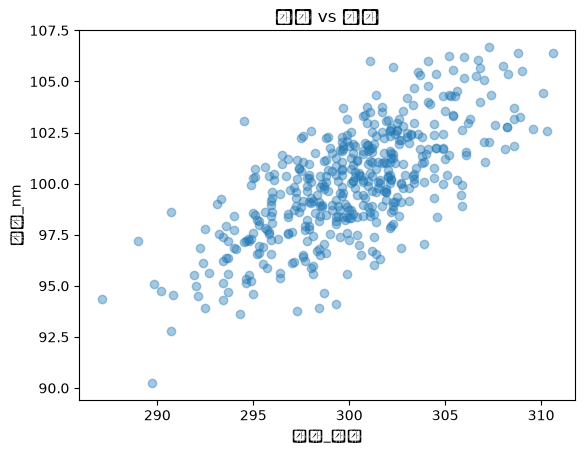

상관계수 r = 0.71


In [4]:
import matplotlib.pyplot as plt

plt.scatter(df["온도_섭씨"], df["두께_nm"], alpha=0.4)
plt.xlabel("온도_섭씨"); plt.ylabel("두께_nm"); plt.title("온도 vs 두께")
plt.show()

r = df["온도_섭씨"].corr(df["두께_nm"])
print("상관계수 r =", round(r, 2))

## 5단계. 습도(대조군)와 불합격의 관계 확인하기
**예상 결과**: r ≈ -0.13, 온도-두께보다 0에 훨씬 가까움.
**설명 포인트**: 상관계수(0.06)만 봤다면 놓쳤을 패턴이 있을 수도 있다는 것과, 반대로
여기서는 '관계가 없다'는 것 자체가 의도된 설계였다는 점을 함께 짚는다.

In [5]:
r_humid = df["습도_pct"].corr(df["불합격여부_숫자"])
print("습도-불합격 상관계수 r =", round(r_humid, 2))

습도-불합격 상관계수 r = -0.13


## 6단계(도전). EQ-02의 진동 값 비교하기
**예상 결과**: EQ-02의 평균 진동이 다른 설비보다 뚜렷하게 높음.

In [6]:
df.groupby("설비번호")["진동_mm_s"].mean().round(3)

설비번호
EQ-01    0.507
EQ-02    0.678
EQ-03    0.503
EQ-04    0.501
Name: 진동_mm_s, dtype: float64

## 7단계. 오늘의 분석을 한 문장으로 정리하기
**진행 방법**: 학생 문장에 "~때문에 불량이 생긴다", "원인이다" 같은 단정 표현이 나오면 그 자리에서 "원인 후보"로 바꿔 말하게 한다. 이 교정이 8차시의 핵심 학습 목표다.
**주의**: 상관관계는 원인을 증명하지 않는다. 5단계 습도(대조군)를 다시 언급하며 "관계가 없는 변수도 함께 확인해야 비교가 된다"는 점을 붙여준다.
**설명 포인트**: 결과 해석 문장 쓰기는 1차시부터 10차시까지 매 차시 빠지지 않는 고정 활동이다(docs/curriculum.md 「차시 간 연결 원칙」). 코드를 친 것으로 끝내지 않고 자기 말로 바꿔 말해보게 하는 것이 이 과정의 목표 — "데이터로 공정 상태를 설명할 수 있는 사람" — 에 직접 닿는 활동이므로 시간이 모자라도 2~3분은 반드시 확보한다.

> (예시 답안) 진공도가 정상 범위를 벗어나면 불합격률이 약 8.06%에서 25.64%로 높아지는 경향이 관찰되어, 진공도 이탈은 불합격의 원인 후보로 볼 수 있다. 다만 상관관계만으로 원인이라고 단정할 수 없으며, 정확한 원인 확인을 위해서는 추가 데이터와 실험이 필요하다.

## 냉각수온도 → 공정온도 시차 패턴(확장, 강사 시연)
시간순으로 정렬한 뒤 냉각수온도가 오른 구간 근처에서 온도도 따라 오르는지 시각적으로 확인.

C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 45257 (\N{HANGUL SYLLABLE NAENG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 46020 (\N{HANGUL S

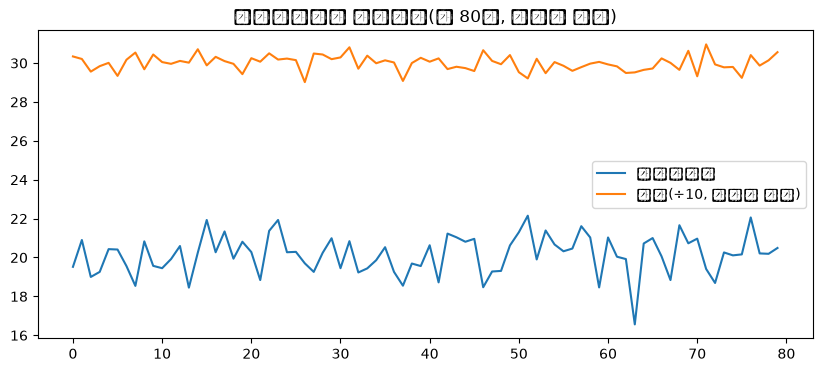

In [7]:
df_sorted = df.sort_values("측정시간").reset_index(drop=True)
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(df_sorted.index[:80], df_sorted["냉각수온도_섭씨"][:80], label="냉각수온도")
ax1.plot(df_sorted.index[:80], df_sorted["온도_섭씨"][:80] / 10, label="온도(÷10, 스케일 맞춤)")
ax1.legend()
ax1.set_title("냉각수온도와 공정온도(앞 80건, 스케일 조정)")
plt.show()

## 오류 대처 방법
- `&`, `|`를 `and`, `or`로 잘못 쓰면 `ValueError`가 발생한다 — Pandas 조건식 규칙을 다시 안내.
- `corr()`는 숫자 열끼리만 계산된다는 점을 다시 강조.

## 확장 실습(빠른 학습자용)
압력_Pa와 불합격 사이의 관계도 같은 방식(임계값 비교)으로 확인해보게 한다.

## 8단계. AI에게 질문하며 더 알아보기
**설명 포인트**: 상관계수 판단 기준 질문이 나오면, "절대적인 기준은 없고 분야·데이터마다
다르다"는 점을 강조해 오늘의 핵심 메시지(상관관계≠원인)와 연결한다.

질문 예시:
- "상관계수(r)가 0.7이면 '강한 상관관계'라고 할 수 있나요? 판단 기준이 있나요?"
- "상관관계와 인과관계는 정확히 어떻게 다른가요?"
- "'대조군(control group)'이라는 개념이 왜 중요한가요?"
- "여러 변수 중 어떤 변수가 불량과 가장 관련 있는지 한 번에 비교하려면 어떻게 하나요?"

## 9단계. AI에게 코드 생성 요청하고 직접 실행해보기
**설명 포인트**: "0.5 기준"은 AI가 임의로 정한 값이라는 점, 그리고 상관계수가 커도 여전히
"원인 후보"일 뿐이라는 점을 다시 한 번 강조한다.

프롬프트 예시: "두 숫자 리스트의 상관계수를 계산하고, 절댓값이 0.5보다 크면 '뚜렷한 관계',
아니면 '약한 관계'라고 출력하는 코드를 만들어줘."

아래는 AI가 생성해줄 수 있는 예시 코드와 실행 결과다.

In [8]:
temp_sample = pd.Series([295.4, 298.1, 312.6, 301.0, 296.8, 305.2])
fail_sample = pd.Series([0, 0, 1, 0, 0, 1])

r = temp_sample.corr(fail_sample)
label = "뚜렷한 관계" if abs(r) > 0.5 else "약한 관계"
print(f"상관계수 r = {r:.2f} → {label}")

상관계수 r = 0.89 → 뚜렷한 관계


## 10단계. 연습문제 — 진동 값과 불합격의 관계 확인하기
**설명 포인트**: 진동_mm_s과 불합격여부_숫자의 상관계수도 온도-두께, 습도-불합격과 마찬가지로
"원인 후보"를 가리키는 신호일 뿐, 그 자체로 원인을 증명하지 않는다는 점을 다시 한 번 짚어준다.

In [9]:
r_vib = df["진동_mm_s"].corr(df["불합격여부_숫자"])
print("진동-불합격 상관계수 r =", round(r_vib, 2))

진동-불합격 상관계수 r = 0.02


## 11단계. AI로 재미있는 미니 프로그램 만들기 🎉 — 원인 후보 추리 게임
**설명 포인트**: 앞서 계산한 온도-두께 상관계수, `r_humid`(습도-불합격), `r_vib`(진동-불합격)을
모아 "게임"처럼 순위를 매겨 보여준다. 절댓값이 클수록 함께 움직이는 정도가 강하다는 감각을
주되, **이 랭킹은 서로 다른 결과에 대한 상관계수를 한 줄에 세운 것**임을 반드시 짚는다 —
온도-두께는 **두께**의 원인 후보를 본 것이고, 습도·진동은 **불합격**의 원인 후보를 본 것이다.
따라서 1위라고 해서 불합격의 가장 유력한 원인 후보가 되는 것이 아니다(강의 「주의 — 그렇다고
온도가 "불합격의" 원인 후보는 아니다」와 같은 내용이다). 출력 문구에서도 "원인"이 아니라
"원인 후보"라는 표현을 반드시 유지해야 함을 강조한다.

**참고(강사용)**: 9단계 AI 예시 코드가 `r`이라는 변수명을 다른 값(temp_sample-fail_sample
상관계수)에 재사용했으므로, 아래 코드는 4단계의 온도-두께 상관계수를 `r_thickness`로 다시
계산해 사용한다. 학생들에게는 "같은 변수 이름을 여러 번 다른 값에 재사용하면 앞의 값을
잃어버릴 수 있다"는 점을 짚어줄 좋은 기회다.

프롬프트 예시: "변수 이름과 상관계수가 담긴 딕셔너리를 받아서, 절댓값이 큰 순서로 정렬해
'용의선상 원인 후보 랭킹'처럼 🔎 이모지와 함께 출력하는 파이썬 코드를 만들어줘."

아래는 AI가 생성해줄 수 있는 예시 코드와 실행 결과다.

In [10]:
r_thickness = df["온도_섭씨"].corr(df["두께_nm"])  # 9단계 예시 코드가 r 변수를 재사용했으므로 다시 계산
suspects = {"온도-두께": r_thickness, "습도-불합격": r_humid, "진동-불합격": r_vib}
ranked_suspects = sorted(suspects.items(), key=lambda item: abs(item[1]), reverse=True)

print("🔎 원인 후보 추리 게임 결과 🔎")
for rank, (name, value) in enumerate(ranked_suspects, start=1):
    print(f"{rank}위 원인 후보: {name} (상관계수 {value:.2f})")

🔎 원인 후보 추리 게임 결과 🔎
1위 원인 후보: 온도-두께 (상관계수 0.71)
2위 원인 후보: 습도-불합격 (상관계수 -0.13)
3위 원인 후보: 진동-불합격 (상관계수 0.02)
